# Image harmonisation using histogram matching

In this example, we will:

1. Load two MRI images acquired from different sessions or scanners.
2. Visualize their intensity histograms.
3. Apply histogram matching to align the intensity distribution of a source image to a reference image.
4. Visualize the histograms again to observe how the intensity distributions change after harmonisation.

Histogram matching is a simple global harmonisation method. It does not modify anatomical structures or spatial information; instead, it adjusts voxel intensity values so that the overall intensity distribution of the source image more closely resembles that of the reference image.

## Test data from ON-Harmony

The test data used in this notebook are stored in the `histmatching_data` folder.

The images are derived from the ON-Harmony dataset ([paper here](https://www.nature.com/articles/s41597-025-04822-2)), which is publicly available through [OpenNeuro](https://openneuro.org/datasets/ds004712/versions/2.0.1).

## Histogram matching in ANTsPy

Before applying histogram matching:

- Bias-field correction should be performed first for e.g., `*_restore*` images in FSL-FAST.
- Brain masking can improve robustness by excluding non-brain voxels.
- Typical workflow: Bias correction (FAST/N4) → optional brain masking → histogram matching

### Important practical notes

This notebook is intended as an illustrative educational example of MRI harmonisation workflows.

For simplicity, some preprocessing and segmentation outputs used in this notebook are provided as precomputed examples for illustration and methodological understanding. These example outputs have not been specifically optimised or quality-controlled for downstream analysis.

In real neuroimaging studies, the following steps are strongly recommended:
- Visual quality control of raw and processed images
- Inspection of brain extraction accuracy
- Verification of tissue segmentation quality
- Careful assessment of harmonisation effects on downstream analyses
- Validation across scanners, sites, and participant groups

Histogram matching can improve consistency of image intensity distributions, but it does not guarantee biologically accurate or unbiased downstream measurements.

In [ ]:
# install packages if not done already
%pip install antspyx nibabel

## Step 1: Inspect the original images

Before matching, we first look at the intensity distributions of the reference and source images.
We remove background voxels so the histograms focus on brain tissue rather than air.

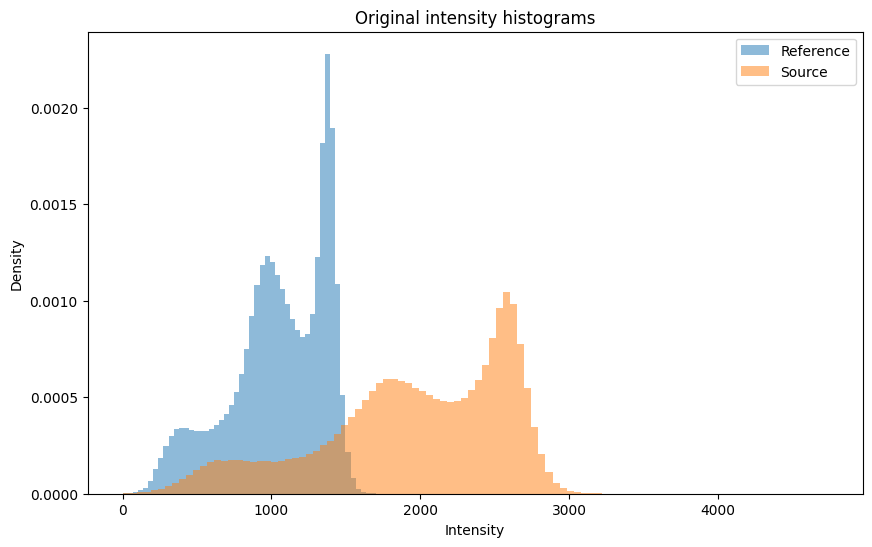

In [31]:
# Imports packages

import os
import numpy as np
import ants 
import matplotlib.pyplot as plt
import nibabel as nib
import pandas as pd
from pathlib import Path

repo_root = Path.cwd().parent.parent
ref_file  = repo_root / "data" / "data_block4" / "histmatching_data" / "sub-03286" / "ses-OXF1PRI001" / "brain_restore.nii.gz"
src_file  = repo_root / "data" / "data_block4" / "histmatching_data" / "sub-03286" / "ses-OXF2PRI001" / "brain_restore.nii.gz"


reference_img = ants.image_read(str(ref_file))
source_img    = ants.image_read(str(src_file))

# Plot original histograms

ref_np = reference_img.numpy()
src_np = source_img.numpy()

ref_vals = ref_np[ref_np > 0]
src_vals = src_np[src_np > 0]

plt.figure(figsize=(10, 6))

plt.hist(ref_vals, bins=100, density=True, alpha=0.5, label="Reference")
plt.hist(src_vals, bins=100, density=True, alpha=0.5, label="Source")

plt.xlabel("Intensity")
plt.ylabel("Density")
plt.title("Original intensity histograms")
plt.legend()
plt.show()

## Step 2: Apply histogram matching

Histogram matching adjusts the source image so that its intensity distribution becomes more similar to the reference image. This is a simple example of harmonisation across scans or sessions.

In [32]:
# Apply histogram matching
matched_img = ants.histogram_match_image(source_img, reference_img)

# Specify output image name with path
output_img  = repo_root / "data" / "data_block4" / "histmatching_data" / "sub-03286" / "ses-OXF2PRI001" / "brain_restore_harmonisedToRef.nii.gz"

ants.image_write(
    matched_img,
    str(output_img)
)

## Step 3: Compare histograms after matching

Now we plot the histogram of the matched image alongside the original reference and source images.
If matching worked well, the matched histogram should look more similar to the reference histogram.

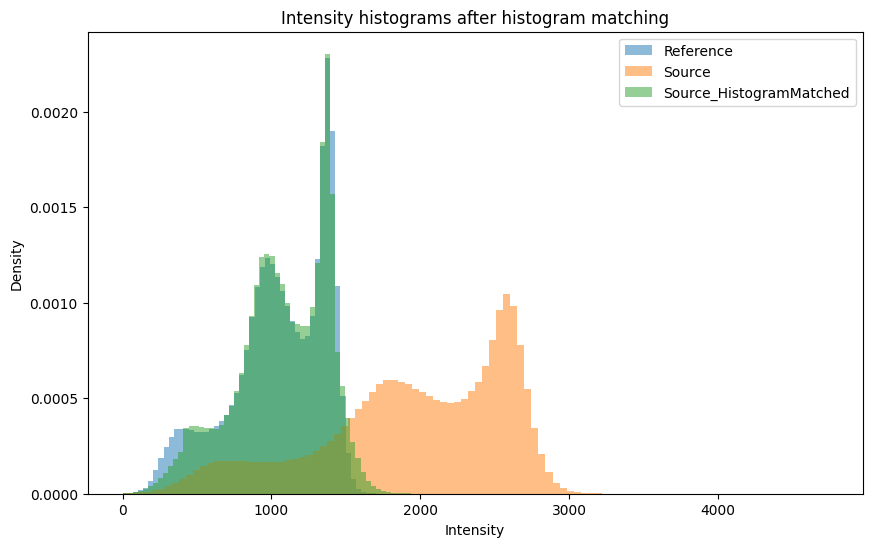

In [33]:
# Plot histogram after matching

match_np = matched_img.numpy()
match_vals = match_np[match_np > 0]

plt.figure(figsize=(10, 6))

plt.hist(ref_vals, bins=100, density=True, alpha=0.5, label="Reference")
plt.hist(src_vals, bins=100, density=True, alpha=0.5, label="Source")
plt.hist(match_vals, bins=100, density=True, alpha=0.5, label="Source_HistogramMatched")

plt.xlabel("Intensity")
plt.ylabel("Density")
plt.title("Intensity histograms after histogram matching")
plt.legend()
plt.show()

## Optional: Visual inspection of the images

Histogram matching changes intensities, so it is also useful to inspect images before and after matching.

### Important visualization note

Image appearance can be strongly influenced by display settings such as intensity windowing and contrast scaling.

For fair visual comparison in this notebook, all images are displayed using a common intensity range. However, visualization within Jupyter notebooks is still simplified compared to dedicated neuroimaging viewers.

For detailed inspection and quality control, it is strongly recommended to use dedicated neuroimaging software such as:

- [FSLeyes](https://fsl.fmrib.ox.ac.uk/fsl/docs/utilities/fsleyes.html)
- [MRICroGL](https://www.nitrc.org/projects/mricrogl/)
- [ITK-SNAP](https://www.itksnap.org/pmwiki/pmwiki.php)
- [Freeview](https://surfer.nmr.mgh.harvard.edu/fswiki/FreeviewGuide/FreeviewIntroduction)
- or any other preferred

These tools provide interactive control over intensity scaling, orientation, overlays, and anatomical navigation, which are important for accurate interpretation and quality assessment.

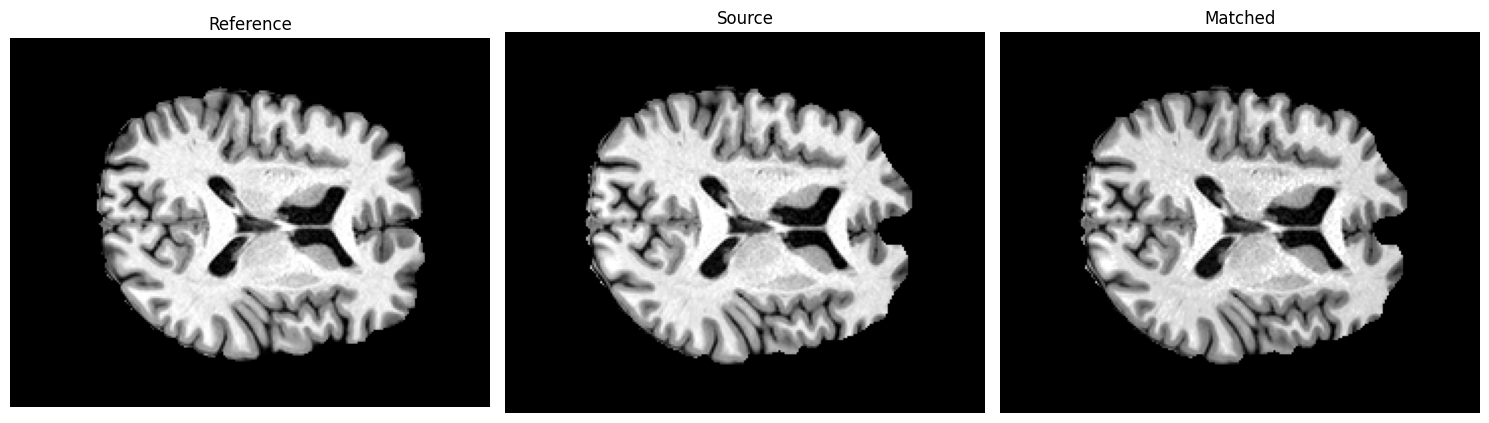

In [34]:
# Slice view: use each image's own middle slice
ref_mid = ref_np.shape[2] // 2
src_mid = src_np.shape[2] // 2
match_mid = match_np.shape[2] // 2

# Separate display ranges for each image
ref_vmin, ref_vmax = np.percentile(ref_np[ref_np > 0], [2, 98])
src_vmin, src_vmax = np.percentile(src_np[src_np > 0], [2, 98])
match_vmin, match_vmax = np.percentile(match_np[match_np > 0], [2, 98])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ref_np[:, :, ref_mid], cmap="gray", vmin=ref_vmin, vmax=ref_vmax)
axes[0].set_title("Reference")
axes[0].axis("off")

axes[1].imshow(src_np[:, :, src_mid], cmap="gray", vmin=src_vmin, vmax=src_vmax)
axes[1].set_title("Source")
axes[1].axis("off")

axes[2].imshow(match_np[:, :, match_mid], cmap="gray", vmin=match_vmin, vmax=match_vmax)
axes[2].set_title("Matched")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Compare downstream tissue volume estimates

Here we use precomputed [FSL-FAST](https://fsl.fmrib.ox.ac.uk/fsl/docs/structural/fast.html) tissue probability maps to estimate tissue volumes. You can find these at this location: `<repo_root>/data/data_block4/histmatching_data/sub-03286`.

FSL-FAST outputs partial-volume estimates for each tissue class. By summing the partial-volume values and multiplying by voxel volume, we obtain an approximate tissue volume.

This comparison is intended as an illustrative example of how histogram matching can affect downstream quantitative measures.

In [35]:
# This function will calculate the volumes for FAST

def tissue_volume_from_pve(pve_path):
    """
    Estimate tissue volume from a FAST partial-volume estimate image.
    
    Parameters
    ----------
    pve_path : str
        Path to a FAST partial-volume estimate NIfTI file.
        
    Returns
    -------
    volume_ml : float
        Estimated tissue volume in mL.
    voxel_volume_mm3 : float
        Volume of one voxel in mm^3.
    shape : tuple
        Image shape.
    """
    img = nib.load(pve_path)
    data = img.get_fdata()

    # Voxel volume in mm^3
    voxel_volume_mm3 = np.prod(img.header.get_zooms()[:3])

    # FAST PVE values are fractional tissue volumes, so sum them
    volume_mm3 = np.sum(data) * voxel_volume_mm3
    volume_ml = volume_mm3 / 1000.0

    return volume_ml, voxel_volume_mm3, data.shape

Image    Reference      Source     Matched
Tissue                                    
CSF     324.223583  308.495414  294.923226
GM      616.658704  579.627509  598.164962
WM      605.131713  609.327077  604.361812


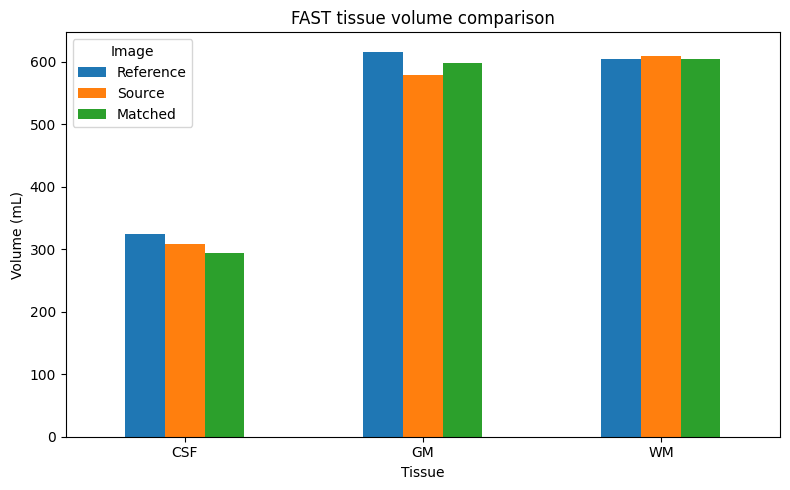

In [36]:
repo_root    = Path.cwd().parent.parent
ref_dir      = repo_root / "data" / "data_block4" / "histmatching_data" / "sub-03286" / "ses-OXF1PRI001" 
src_dir      = repo_root / "data" / "data_block4" / "histmatching_data" / "sub-03286" / "ses-OXF2PRI001" 
matched_dir  = repo_root / "data" / "data_block4" / "histmatching_data" / "sub-03286" / "ses-OXF2PRI001" / "prebaked_fast_harmonised"

# Example file layout
reference_dir = str(ref_dir)
source_dir    = str(src_dir)
matched_dir   = str(matched_dir) 

# FAST tissue classes
# pve_0 = CSF
# pve_1 = GM
# pve_2 = WM

paths = {
    "Reference_CSF": os.path.join(reference_dir, "brain_pve_0.nii.gz"),
    "Reference_GM":  os.path.join(reference_dir, "brain_pve_1.nii.gz"),
    "Reference_WM":  os.path.join(reference_dir, "brain_pve_2.nii.gz"),

    "Source_CSF": os.path.join(source_dir, "brain_pve_0.nii.gz"),
    "Source_GM":  os.path.join(source_dir, "brain_pve_1.nii.gz"),
    "Source_WM":  os.path.join(source_dir, "brain_pve_2.nii.gz"),

    "Matched_CSF": os.path.join(matched_dir, "src_image_harmonised_pve_0.nii.gz"),
    "Matched_GM":  os.path.join(matched_dir, "src_image_harmonised_pve_1.nii.gz"),
    "Matched_WM":  os.path.join(matched_dir, "src_image_harmonised_pve_2.nii.gz"),
}

rows = []
for label, path in paths.items():
    vol_ml, voxel_vol_mm3, shape = tissue_volume_from_pve(path)
    image_type, tissue = label.split("_")
    rows.append({
        "Image": image_type,
        "Tissue": tissue,
        "Volume_mL": vol_ml,
        "VoxelVolume_mm3": voxel_vol_mm3,
        "Shape": shape
    })
df = pd.DataFrame(rows)
table = df.pivot(index="Tissue", columns="Image", values="Volume_mL")
table = table[["Reference", "Source", "Matched"]]
print(table)
ax = table.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Volume (mL)")
ax.set_title("FAST tissue volume comparison")
ax.legend(title="Image")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Interpretation

If histogram matching improves intensity consistency, the estimated tissue volumes for the matched image may move closer to those of the reference image. This does not imply that the underlying anatomy changed. Rather, the intensity representation became more similar, which can influence intensity-based downstream processing.

## Exercise: does histogram matching help?

Choose one pair of repeated scans from the same participant (you can download from [here](https://openneuro.org/datasets/ds004712/versions/2.0.1)).

1. Compare the original histograms.
2. Apply histogram matching.
3. Compare the histograms again.
4. Decide whether the matched image looks closer to the reference image.

Discussion:
- Does histogram matching work better for repeated scans from the same scanner?
- Does it still help when the scans come from different scanners or vendors?
- Where does it start to fail?

### Solution

We downloaded data from one of the participants from this [link]((https://openneuro.org/datasets/ds004712/versions/2.0.1)). You can check the solutions of this notebook [here](https://github.com/N-Nieto/OHBM2026_Educational_course_harmonization/tree/main/solutions/block04/B4_N2_histmatching_exercise).

- `Source Image`: *sub-03286_ses-OXF3TRI001_T1w.nii.gz* (Siemens Trio)
- `Reference Image`: *sub-03286_ses-OXF1PRI001_T1w.nii.gz* (Siemens Prisma)
- Perform brain extraction (FSL-BET)
- Perform FAST segmentation and store bias corrected output (FSL-FAST); alternatively you can use ANTs tools for bias correction as well
- Use `_restore.nii.gz` for histogram matching

See code below which will compare the original histograms, apply histogram matching.

### Discussion: Histogram Matching Across Scanner Vendors

Histogram matching can be an effective intensity normalization technique when comparing scans acquired on the same scanner or scanners from the same manufacturer (*As seen in example in the original workbook when we used repeat scans from same scanner and model e.g., Siemens Prisma; as well as example below when we used repeat scans from same scanner but different model e.g., Siemens Prisma and Siemens Trio*). In these situations, the underlying intensity distributions are often similar, and histogram matching can improve visual consistency between images. However, when comparing images acquired across different scanner vendors (e.g., Siemens, GE, Philips), the intensity distributions may differ substantially due to variations in hardware, reconstruction algorithms, coil configurations, and acquisition protocols. It is important to recognise that MRI intensities do not have a fixed physical scale. Histogram matching therefore attempts to force one intensity distribution to resemble another, even when the relationship between tissue intensities differs across scanners. As a result, histogram matching should be viewed as a simple intensity normalisation method rather than a comprehensive harmonisation strategy.

**Key takeaway:** Histogram matching often works well for repeated scans or images acquired on similar scanner platforms, but its performance may degrade when applied across different vendors or acquisition protocols. More advanced harmonisation approaches (see below) are typically more appropriate for multi-site and multi-vendor studies.

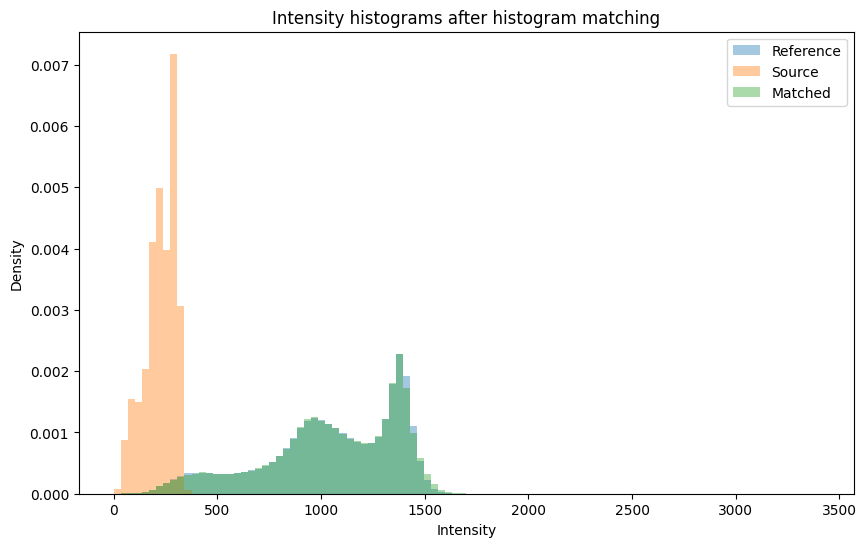

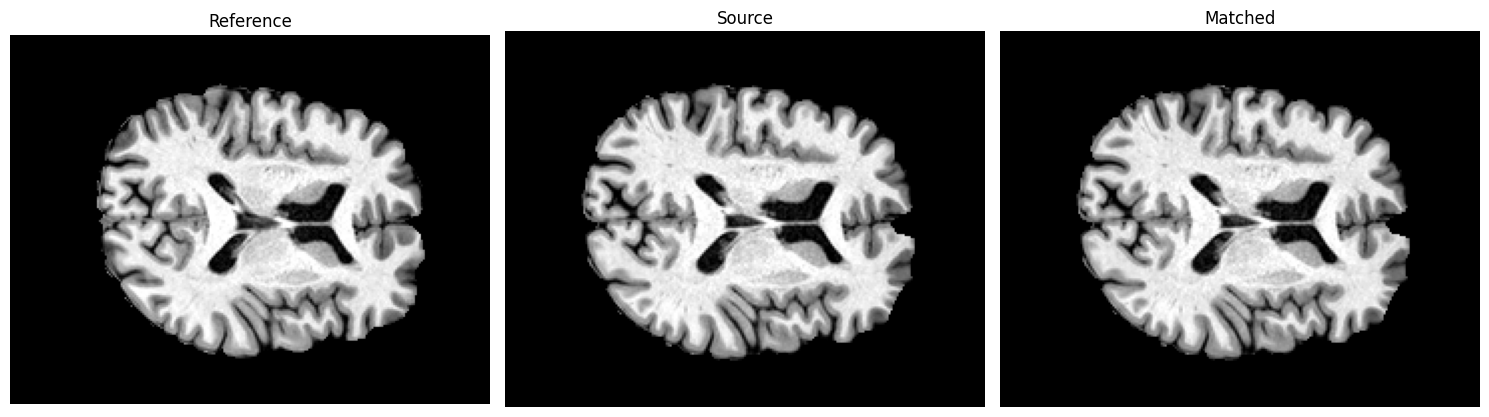

In [39]:
import ants
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

repo_root = Path.cwd().parent.parent

ref_file = repo_root / "solutions" / "block04" / "B4_N2_histmatching_exercise" / "sub-03286" / "ses-OXF1PRI001" / "brain_restore.nii.gz"
src_file = repo_root / "solutions" / "block04" / "B4_N2_histmatching_exercise" / "sub-03286" / "ses-OXF3TRI001" / "brain_restore.nii.gz"

reference_img = ants.image_read(str(ref_file))
source_img = ants.image_read(str(src_file))

ref_np = reference_img.numpy()
src_np = source_img.numpy()

ref_vals = ref_np[ref_np > 0]
src_vals = src_np[src_np > 0]

# Histogram match
matched_img = ants.histogram_match_image(source_img, reference_img)

output_img = repo_root / "solutions" / "block04" / "B4_N2_histmatching_exercise" / "sub-03286" / "ses-OXF3TRI001" / "brain_restore_harmonisedToRef.nii.gz"
ants.image_write(matched_img, str(output_img))

match_np = matched_img.numpy()
match_vals = match_np[match_np > 0]

# Use shared bin edges for a fair comparison
all_vals = np.concatenate([ref_vals, src_vals, match_vals])
bin_edges = np.histogram_bin_edges(all_vals, bins=100)

plt.figure(figsize=(10, 6))
plt.hist(ref_vals, bins=bin_edges, density=True, alpha=0.4, label="Reference")
plt.hist(src_vals, bins=bin_edges, density=True, alpha=0.4, label="Source")
plt.hist(match_vals, bins=bin_edges, density=True, alpha=0.4, label="Matched")
plt.xlabel("Intensity")
plt.ylabel("Density")
plt.title("Intensity histograms after histogram matching")
plt.legend()
plt.show()

# Slice view: use each image's own middle slice 
ref_mid = ref_np.shape[2] // 2
src_mid = src_np.shape[2] // 2
match_mid = match_np.shape[2] // 2

# Separate display ranges for each image
ref_vmin, ref_vmax = np.percentile(ref_np[ref_np > 0], [2, 98])
src_vmin, src_vmax = np.percentile(src_np[src_np > 0], [2, 98])
match_vmin, match_vmax = np.percentile(match_np[match_np > 0], [2, 98])

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(ref_np[:, :, ref_mid], cmap="gray", vmin=ref_vmin, vmax=ref_vmax)
axes[0].set_title("Reference")
axes[0].axis("off")

axes[1].imshow(src_np[:, :, src_mid], cmap="gray", vmin=src_vmin, vmax=src_vmax)
axes[1].set_title("Source")
axes[1].axis("off")

axes[2].imshow(match_np[:, :, match_mid], cmap="gray", vmin=match_vmin, vmax=match_vmax)
axes[2].set_title("Matched")
axes[2].axis("off")

plt.tight_layout()
plt.show()


## Advanced Image-Level Harmonisation Approaches
---

A growing number of methods aim to address scanner and acquisition variability directly at the image level, often using deep learning, synthesis, segmentation, or domain-adaptation frameworks. These approaches can substantially improve robustness across heterogeneous datasets, particularly in multi-site neuroimaging studies.

Some widely used and emerging tools include:

* **SynthSR**
  A deep-learning framework for generating high-resolution synthetic MRI volumes with improved contrast consistency across acquisitions and resolutions. More details [here](https://surfer.nmr.mgh.harvard.edu/fswiki/SynthSR).

* **SynthSeg**
  A contrast-agnostic segmentation framework capable of robust anatomical segmentation across varying scanners, contrasts, and acquisition protocols. More details [here](https://surfer.nmr.mgh.harvard.edu/fswiki/SynthSeg).

* **Recon-all-Clinical**
  An optimised FreeSurfer-based pipeline designed for clinical-quality scans, incorporating robust preprocessing and segmentation strategies for heterogeneous datasets. More details [here](https://surfer.nmr.mgh.harvard.edu/fswiki/recon-all-clinical).

* **HaCa3**
  A harmonisation-oriented framework designed to improve cross-site consistency while preserving biologically meaningful image characteristics. More details [here](https://doi.org/10.1016/j.compmedimag.2023.102285). 

* **CALAMITI**
  A deep-learning-based MRI harmonisation framework targeting scanner-related intensity variability. More details [here](https://iacl.ece.jhu.edu/index.php?title=CALAMITI).

* **DeepHarmony**
  A supervised image harmonisation approach that learns scanner mappings using paired acquisitions. More details [here](https://doi.org/10.1016/j.mri.2019.05.041).

* **MISPEL**
  A multi-scanner image harmonisation framework using disentangled representation learning. More details [here](https://doi.org/10.1016/j.media.2023.102926).

* **CycleGAN / GAN-based harmonisation approaches**
  Unpaired image translation methods frequently used for cross-scanner or cross-domain MRI harmonisation. More details [here](https://github.com/Iceberg6618/CycleGAN-Harmonization).

* **RAVEL / WhiteStripe / Nyúl standardisation**
  Classical intensity-standardisation methods commonly used to reduce scanner-related intensity variation prior to downstream analysis. More details [here](https://doi.org/10.1016/j.neuroimage.2021.118703).


## Why These Methods Are Not Included in This Course

Although highly valuable in research settings, these advanced image-level harmonisation methods are intentionally not included as executable components of this educational course.

This is primarily because:

* installation and environment setup can become highly platform-dependent,
* implementations often require complex software dependencies,
* GPU acceleration may be necessary for practical runtimes,
* preprocessing requirements can differ substantially across methods,
* computational demands may exceed lightweight educational environments,
* some pipelines require substantial storage and memory resources,
* reproducibility may vary across operating systems and software versions.

In addition, many image-level harmonisation frameworks require careful dataset-specific optimisation, quality control, and validation before research deployment.

For these reasons, this course focuses on lightweight, interpretable, and reproducible educational examples that illustrate the core methodological concepts without imposing substantial computational or infrastructure requirements.
